# Implement folder Planck equation

Use to do Ag selection in antigen cocktails

In [25]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")


In [26]:
p_sil=0.75# 10-3 mutation rate times nb of amino acids=250 so total is 0.25 mutation per cycle
p_let=0.05*(1-p_sil)
p_aa=0.95*(1-p_sil)
mu_M=-0.13*np.log(10)
sigma_M=0.37*np.log(10)
S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}

E_a=3.4                        # Ag-gate threshold
kBT=1                       # thermal factor
N_i=2000  
N_max=2000 
mu_i=0.0 
sigma_i=0.1
p_diff=0.10


    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)

In [27]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    S_mat=None,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=N_i,  N_max=N_max,
    # grid / time ----------------------------------------------------------
    h_min=-10.0, h_max=10.0, d_h=0.1,
    T=30.0,  dt=0.01,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if S_mat is None:
        raise ValueError("S_mat (binary motif matrix) must be provided")
    N_h, n_A = S_mat.shape          # k = dimension of h



    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  =  eE.sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max+0.1 else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



In [28]:
def run_fp(S_mat, get_C, *, T=20.0, verbose=False):
    """
    Returns a dict 'fp_ctx' with everything downstream functions need.
    """
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        S_mat=S_mat, get_C=get_C, T=T, verbose=verbose
    )

    # ---------- Φ̄(t_k) --------------------------------------------
    N_h, n_A  = S_mat.shape
    d_h       = axes[0][1] - axes[0][0]
    dH        = d_h**N_h
    h_mesh    = np.meshgrid(*axes, indexing="ij")
    E_full    = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))

    Phi_bar = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = ( np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)

    # ---------- Γ & ∇Γ snapshots (autograd) ------------------------
    S_torch = torch.tensor(S_mat, dtype=torch.float64)
    gamma_list, grad_list = [], []

    for k, t_now in enumerate(times):
        Phi_b  = float(Phi_bar[k])
     
        omega  = float(omegas[k])
        C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)], dtype=float)
        C_t    = torch.tensor(C_vec, dtype=torch.float64)

        def γ(h_t, C_t=C_t, Phi_b=Phi_b, omega=omega):
            E_v  = torch.mv(S_torch.T, h_t)
            P_Ag = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
            P_Ag = P_Ag / (1.0 + P_Ag)
            Phi  = torch.exp(E_v / kBT).sum()
            P_T  = Phi / (Phi + Phi_b / C_t.sum())
            return lam + torch.log(P_Ag) + torch.log(P_T) - omega

        def gγ_np(h_np, γ=γ):          # capture γ itself
            h_t = torch.tensor(h_np, requires_grad=True, dtype=torch.float64)
            γ(h_t).backward()
            return h_t.grad.numpy()

        gamma_list.append(γ)
        grad_list.append(gγ_np)

    return dict(
        axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        Phi_bar=Phi_bar,
        gamma_list=gamma_list, grad_list=grad_list,
        S_mat=S_mat, get_C=get_C
    )



In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_density_time_dim(fp_ctx, dim=0, *,
                             disp_step=5, cmap="viridis",
                             sol=None, t_clip=5.0):
    """
    Heat-map of ρ(t, h_dim), with colour-bar max taken from times ≥ t_clip.

    Parameters
    ----------
    fp_ctx   : dict   – output of run_fp
    dim      : int    – which h-coordinate to show (0-based)
    disp_step: float  – x-tick spacing
    cmap     : str    – Matplotlib colormap
    sol      : BVPResult or None – optional trajectory overlay
    t_clip   : float  – ignore times < t_clip when computing vmax
    """
    axes, times, rho_t = fp_ctx["axes"], fp_ctx["times"], fp_ctx["rho_t"]
    N_h = len(axes)
    if not (0 <= dim < N_h):
        raise ValueError(f"dim must be in [0,{N_h-1}]")

    h_axis = axes[dim]

    # --- marginal over all dims except `dim` --------------------------
    marginal_axes = tuple(i + 1 for i in range(N_h) if i != dim)  # +1 for time
    dH = np.prod([(axes[i][1] - axes[i][0]) for i in range(N_h)
                  if i != dim]) if N_h > 1 else 1.0
    rho_marg = rho_t.sum(axis=marginal_axes) * dH                 # (n_t, n_h)

    # --- choose vmax from t ≥ t_clip ----------------------------------
    idx_start = np.searchsorted(times, t_clip)          # first t ≥ t_clip
    vmax_clip = rho_marg[idx_start:].max()

    # --- plot ----------------------------------------------------------
    plt.figure(figsize=(8, 5))
    im = plt.imshow(rho_marg.T, origin="lower", aspect="auto",
                    extent=[times[0], times[-1], h_axis[0], h_axis[-1]],
                    cmap=cmap, vmin=0.0, vmax=vmax_clip)

    plt.colorbar(im, label=rf"$\rho(t,h_{{{dim+1}}})$")
    plt.xlabel("Time", fontsize=14)
    plt.ylabel(rf"$h_{{{dim+1}}}$", fontsize=14)
    plt.title(rf"Density $\rho(t,h_{{{dim+1}}})$ ")

    plt.xticks(np.arange(times[0], times[-1] + 1e-9, disp_step))

    if sol is not None:
        plt.plot(sol.x, sol.y[dim], color="red", lw=1.4,
                 label=rf"least-action $h_{{{dim+1}}}(t)$")
        plt.legend()

    plt.tight_layout()
    plt.show()





In [30]:
def make_grad_Gamma(fp_ctx):
    times, grads = fp_ctx["times"], fp_ctx["grad_list"]
    def grad(h, t):
        if t <= times[0]:  return grads[0](h)
        if t >= times[-1]: return grads[-1](h)
        hi = np.searchsorted(times, t)
        lo = hi - 1
        w  = (t-times[lo])/(times[hi]-times[lo])
        return (1.-w)*grads[lo](h) + w*grads[hi](h)
    return grad
from scipy.integrate import solve_bvp

def solve_optimal_trajectory(
        hf, fp_ctx, *, mesh=300, max_nodes=20_000, plot=False):
    """
    Computes the least-action trajectory from h(t0)=0 to h(tf)=hf.
    Works for arbitrary dimensionality N = fp_ctx["S_mat"].shape[0].
    """
    # ---------------- basic info ----------------
    times   = fp_ctx["times"]
    grad_G  = make_grad_Gamma(fp_ctx)
    t0, tf  = times[0], times[-1]
    N       = fp_ctx["S_mat"].shape[0]          # number of h coordinates

    # ------------- final boundary vector -------------
    if np.isscalar(hf):
        hf = np.repeat(float(hf), N)            # same target for every dim
    else:
        hf = np.asarray(hf, dtype=float)
        if hf.size != N:
            raise ValueError(
                f"hf must have length {N} (one per shape dim); got {hf.size}")

    # ----------------- ODE system --------------------
    # state y = (h, v)  ⇒  size 2N
    def ode(t, y):
        h, v = y[:N], y[N:]                      # each is shape (N, len(t))
        a    = np.empty_like(h)
        for j, tj in enumerate(t):               # loop over mesh points
            a[:, j] = -D * grad_G(h[:, j], tj)   # acceleration
        return np.vstack((v, a))

    # ------------- boundary conditions --------------
    def bc(ya, yb):
        # ya[:N]  : h(t0)  ;  yb[:N] : h(tf)
        return np.hstack((ya[:N], yb[:N] - hf))

    # ------------- initial mesh & guess -------------
    t_mesh  = np.linspace(t0, tf, mesh)
    y_guess = np.zeros((2 * N, mesh))
    for i in range(N):                           # linear interpolation guess
        y_guess[i] = hf[i] * (t_mesh - t0) / (tf - t0)

    # ------------- solve BVP ------------------------
    sol = solve_bvp(ode, bc, t_mesh, y_guess, max_nodes=max_nodes)
    if not sol.success:
        raise RuntimeError(sol.message)

    # ------------- optional plot --------------------
    if plot:
        plt.figure(figsize=(6, 3))
        for i in range(N):
            plt.plot(sol.x, sol.y[i], label=rf"$h_{i+1}$")
        plt.xlabel("time")
        plt.ylabel("shape coordinate")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return sol


def compute_least_action(sol, fp_ctx, *, baseline=True, verbose=False):
    """
    Return S_opt   (and S_lin when baseline=True)
    Compatible with any number N = S_mat.shape[0] of shape coordinates.
    """
    # ------------------------------------------------------------------
    times   = fp_ctx["times"]
    omegas  = fp_ctx["omegas"]
    Phi_bar = fp_ctx["Phi_bar"]
    get_C   = fp_ctx["get_C"]
    S_mat   = fp_ctx["S_mat"]
    n_A     = S_mat.shape[1]
    N       = S_mat.shape[0]               # number of h coordinates

    # constants (assumed already defined in the notebook)
    v_vec   = f_aa * mu_M * np.ones(N)     # deterministic drift term

    # --- torch version of S_mat for Γ --------------------------------
    S_T     = torch.tensor(S_mat, dtype=torch.float64)

    # -------------------- Γ(t, h) ------------------------------------
    def Γ(t, h_np):
        """
        Growth rate minus omega at time t and shape h (numpy array length N).
        Returns a scalar float.
        """
        # match given t to nearest entry in 'times'
        k      = int(np.argmin(np.abs(times - t)))
        omega  = omegas[k]
        Phi_b  = Phi_bar[k]

        C_vec  = np.array([get_C(float(times[k]), v) for v in range(n_A)],
                          dtype=float)

        # torch variables
        h_t = torch.tensor(h_np, dtype=torch.float64)
        C_t = torch.tensor(C_vec, dtype=torch.float64)

        # energy of each antigen
        E_v = torch.mv(S_T.T, h_t)         # shape (n_A,)

        # binding probability to target antigen
        PAg = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
        PAg = PAg / (1.0 + PAg)

        # total binding probability (any antigen)
        Phi = (torch.exp(E_v / kBT)).sum()
        PT  = Phi / (Phi + Phi_b / C_t.sum())

        return (lam + torch.log(PAg) + torch.log(PT) - omega).item()

    # ----------------- extract optimal traj ---------------------------
    t_mesh = sol.x                       # shape (m,)
    h_opt  = sol.y[:N].T                 # shape (m, N)
    v_opt  = sol.y[N:2*N].T              # shape (m, N)

    # ----------------- action functional ------------------------------
    def S_of(h, v):
        g    = np.array([Γ(ti, hi) for ti, hi in zip(t_mesh, h)])
        kin  = np.sum((v - v_vec) ** 2, axis=1) / (2 * D)
        return -np.trapz(g - kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)
    if not baseline:
        if verbose:
            print(f"S_opt = {S_opt:.6e}")
        return S_opt

    # ---------------- linear baseline trajectory ----------------------
    slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])      # vector length N
    h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope[None, :]
    v_lin  = np.tile(slope, (len(t_mesh), 1))
    S_lin  = S_of(h_lin, v_lin)

    if verbose:
        print(f"S_opt = {S_opt:.6e}   S_lin = {S_lin:.6e}   ΔS = {S_lin - S_opt:.6e}")

    return S_opt, S_lin


Optimal trajectory: (300,) with shape (4, 300)


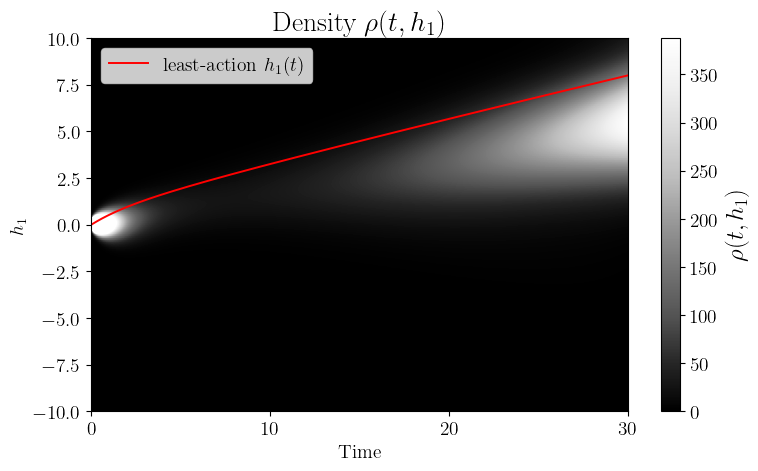

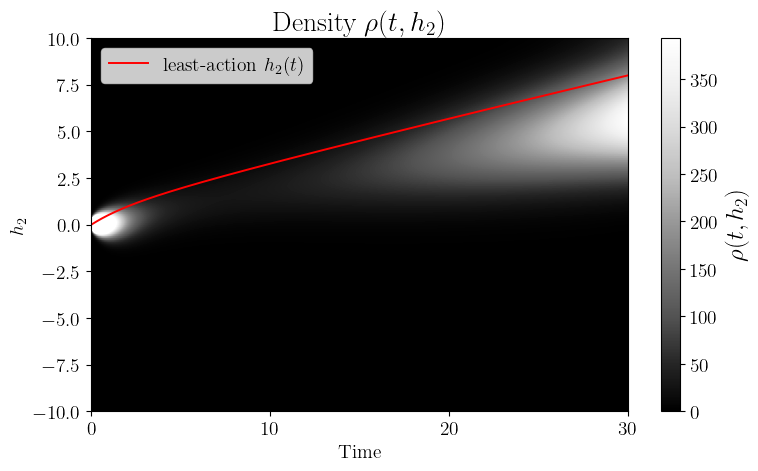

S_opt = 3.979616e+00   S_lin = 5.308753e+00   ΔS = 1.329138e+00


In [31]:

import copy
def f(t,v):
    return 10 if v==0 else 0
fp_ctx = run_fp(
S_mat=np.array([[1.0, 0], [1.0, 1.0]]),  # 2D shape space: h₁ and h₂
get_C=f,
T=30,
verbose=False
)
fp_ctx_safe = copy.deepcopy(fp_ctx)
sol = solve_optimal_trajectory([8,8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx, sol=sol, disp_step=10, cmap="Greys_r", dim=0)
plot_fp_density_time_dim(fp_ctx, sol=sol, disp_step=10, cmap="Greys_r", dim=1)

S,_=compute_least_action(sol, fp_ctx, verbose=True)



# Same with pytorch

In [ ]:
# import torch

# def compute_least_action_torch(
#     sol,
#     fp_ctx,
#     C_param,                  # torch.nn.Parameter, shape (n_times,) or scalar
#     *, baseline=True, verbose=False, rtol=1e-8, atol=1e-10
# ):
#     """
#     PyTorch replica of `compute_least_action` with a learnable C(t).

#     Returns
#     -------
#     S_opt            – torch scalar (action along optimal path)
#     S_lin (optional) – torch scalar (linear-path action) if baseline=True
#     """

#     # --------------------------------------------------------------
#     # 0 · unpack & sanity-check
#     # --------------------------------------------------------------
#     dtype   = torch.float64
#     device  = C_param.device

#     times   = torch.as_tensor(fp_ctx["times"],   dtype=dtype, device=device)
#     omegas0 = torch.as_tensor(fp_ctx["omegas"],  dtype=dtype, device=device)   # reference
#     Phi0    = torch.as_tensor(fp_ctx["Phi_bar"], dtype=dtype, device=device)   # reference

#     rho_np  = fp_ctx["rho_t"]                         # list of numpy arrays (…grid…)
#     axes_np = fp_ctx["axes"]                          # tuple of 1-D axes
#     S_mat   = torch.as_tensor(fp_ctx["S_mat"], dtype=dtype, device=device)


#     n_times = times.numel()
#     N_h, n_A = S_mat.shape

#     # broadcast C_param
#     if C_param.ndim == 0:
#         C_t = C_param.expand(n_times)
#     elif C_param.numel() == n_times:
#         C_t = C_param
#     else:
#         raise ValueError("C_param must be scalar or length n_times")

#     # grid constants
#     d_h  = axes_np[0][1] - axes_np[0][0]
#     dH   = d_h ** N_h
#     axes_t = [torch.as_tensor(ax, dtype=dtype, device=device) for ax in axes_np]
#     H_mesh = torch.meshgrid(*axes_t, indexing="ij")
#     H_stack= torch.stack(H_mesh, dim=0)                       # (N_h,*grid)

#     E_stack     = torch.tensordot(S_mat.T, H_stack, dims=([1],[0]))  # (n_A,*grid)
#     exp_E       = torch.exp(E_stack / kBT)
#     exp_Eshift  = torch.exp((E_stack - E_a) / kBT)

#     Phi_grid       = exp_E.sum(dim=0)         # Σ_v e^{E_v/kBT}
#     PAg_numer_grid = exp_Eshift               # Σ_v e^{(E_v-E_a)/kBT}

#     rho_t = [torch.as_tensor(r, dtype=dtype, device=device) for r in rho_np]

#     # --------------------------------------------------------------
#     # 1 · recompute Φ̄(t_k) and Ω(t_k) with the supplied C(t)
#     # --------------------------------------------------------------
#     Phi_bar = torch.empty_like(times)
#     Omega   = torch.empty_like(times)

#     for k in range(n_times):
#         Ck       = C_t[k]                           # scalar (requires_grad)
#         N_pop    = rho_t[k].sum() * dH

#         # Φ̄(t_k)  (independent of C)
#         Phi_bar_k = (rho_t[k] * Phi_grid).sum() * dH / N_pop
#         Phi_bar[k] = Phi_bar_k

#         # selection log-gain per grid point
#         numer_PAg = Ck * PAg_numer_grid
#         P_Ag_grid = numer_PAg / (1. + numer_PAg)

#         C_tot     = n_A * Ck
#         P_T_grid  = Phi_grid / (Phi_grid + Phi_bar_k / C_tot)

#         log_sel   = torch.log(P_Ag_grid) + torch.log(P_T_grid)
#         avg_log   = (rho_t[k] * log_sel).sum() * dH / N_pop

#         if N_pop < N_max+0.1:
#             Omega[k] = 0.0
#         else:
#             Omega[k] = torch.maximum(torch.zeros((), dtype=dtype, device=device),
#                                      lam + avg_log)

#     # --------------------------------------------------------------
#     # 2 · debug: compare with reference values (optional)
#     # --------------------------------------------------------------
#     if verbose:
#         phi_diff   = torch.max(torch.abs(Phi_bar - Phi0) / Phi0.clamp_min(1e-12))
#         omega_diff = torch.max(torch.abs(Omega   - omegas0) /
#                                omegas0.clamp_min(1e-12))
#         print(f"max rel error Φ̄: {phi_diff.item():.3e}")
#         print(f"max rel error Ω : {omega_diff.item():.3e}")

#         #show indexes of biggest differences
#         if phi_diff > rtol or omega_diff > rtol:
#             idx_phi = torch.argmax(torch.abs(Phi_bar - Phi0) / Phi0.clamp_min(1e-12))
#             idx_omega = torch.argmax(torch.abs(Omega - omegas0) /
#                                      omegas0.clamp_min(1e-12))
#             print(f"max Φ̄ diff at index {idx_phi.item()}: "
#                   f"{Phi_bar[idx_phi].item():.3e} vs {Phi0[idx_phi].item():.3e}")
#             print(f"max Ω  diff at index {idx_omega.item()}: "
#                   f"{Omega[idx_omega].item():.3e} vs {omegas0[idx_omega].item():.3e}")


#     # assert close enough (can be relaxed)
#     # torch.testing.assert_close(Phi_bar, Phi0, rtol=rtol, atol=atol)
#     # torch.testing.assert_close(Omega,   omegas0, rtol=rtol, atol=atol)

#     # --------------------------------------------------------------
#     # 3 · extract optimal trajectory (SciPy solution)
#     # --------------------------------------------------------------
#     t_mesh = torch.as_tensor(sol.x,              dtype=dtype, device=device)  # (m,)
#     h_opt  = torch.as_tensor(sol.y[:N_h].T,      dtype=dtype, device=device)  # (m,N_h)
#     v_opt  = torch.as_tensor(sol.y[N_h:2*N_h].T, dtype=dtype, device=device)  # (m,N_h)

#     v_pref = torch.full((N_h,), f_aa * mu_M, dtype=dtype, device=device)

#     def idx(t):
#         return torch.argmin(torch.abs(times - t))

#     # --------------------------------------------------------------
#     # 4 · Γ(t,h) using the new Ω and Φ̄
#     # --------------------------------------------------------------
#     def Gamma(t, h):
#         k       = idx(t)
#         omega_k = Omega[k]
#         Phi_b   = Phi_bar[k]
#         Ck      = C_t[k]
#         C_vec   = Ck.expand(n_A)

#         E_v = torch.mv(S_mat.T, h)
#         P_Ag = (C_vec * torch.exp((E_v - E_a) / kBT)).sum()
#         P_Ag = P_Ag / (1. + P_Ag)

#         Phi  = torch.exp(E_v / kBT).sum()
#         P_T  = Phi / (Phi + Phi_b / (n_A * Ck))

#         return lam + torch.log(P_Ag) + torch.log(P_T) - omega_k

#     # --------------------------------------------------------------
#     # 5 · action functional
#     # --------------------------------------------------------------
#     def S_of(h, v):
#         g_vals = torch.stack([Gamma(ti, hi) for ti, hi in zip(t_mesh, h)])  # (m,)
#         kin    = ((v - v_pref).pow(2).sum(dim=1)) / (2. * D)               # (m,)
#         return -torch.trapz(g_vals - kin, t_mesh)

#     S_opt = S_of(h_opt, v_opt)

#     if not baseline:
#         return S_opt

#     # linear reference
#     slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])
#     h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope
#     v_lin  = slope.repeat(t_mesh.numel(), 1)
#     S_lin  = S_of(h_lin, v_lin)

#     return S_opt, S_lin


In [33]:
import torch

def compute_least_action_torch_bis(
    sol,
    fp_ctx,
    C_param,                  # scalar, (n_times,) or (n_times,n_A)
    *, baseline=True, verbose=False, rtol=1e-8, atol=1e-10
):
    dtype   = torch.float64
    device  = C_param.device

    # ------------------------------------------------------------------
    # 0 · unpack & sanity-check
    # ------------------------------------------------------------------
    times   = torch.as_tensor(fp_ctx["times"],   dtype=dtype, device=device)
    omegas0 = torch.as_tensor(fp_ctx["omegas"],  dtype=dtype, device=device)   # reference
    Phi0    = torch.as_tensor(fp_ctx["Phi_bar"], dtype=dtype, device=device)   # reference

    rho_np  = fp_ctx["rho_t"]
    axes_np = fp_ctx["axes"]
    S_mat   = torch.as_tensor(fp_ctx["S_mat"], dtype=dtype, device=device)

    n_times = times.numel()
    N_h, n_A = S_mat.shape

    # ---- broadcast C_param to matrix (n_times, n_A) -------------------
    if C_param.ndim == 0:                     # scalar
        C_mat = C_param.expand(n_times, n_A)
    elif C_param.ndim == 1 and C_param.numel() == n_times:
        C_mat = C_param[:, None].expand(n_times, n_A)             # shared curve
    elif C_param.ndim == 2 and C_param.shape == (n_times, n_A):
        C_mat = C_param
    else:
        raise ValueError(
            "C_param must be scalar, shape (n_times,) or (n_times, n_A)"
        )

    # ------------------------------------------------------------------
    # grid constants
    # ------------------------------------------------------------------
    d_h  = axes_np[0][1] - axes_np[0][0]
    dH   = d_h ** N_h
    axes_t = [torch.as_tensor(ax, dtype=dtype, device=device) for ax in axes_np]
    H_mesh = torch.meshgrid(*axes_t, indexing="ij")
    H_stack= torch.stack(H_mesh, dim=0)                       # (N_h,*grid)

    E_stack     = torch.tensordot(S_mat.T, H_stack, dims=([1],[0]))  # (n_A,*grid)
    exp_E       = torch.exp(E_stack / kBT)
    exp_Eshift  = torch.exp((E_stack - E_a) / kBT)

    Phi_grid       = exp_E.sum(dim=0)         # Σ_v e^{E_v/kBT}
    PAg_numer_grid = exp_Eshift               # shape (n_A,*grid)

    rho_t = [torch.as_tensor(r, dtype=dtype, device=device) for r in rho_np]

    # ------------------------------------------------------------------
    # 1 · recompute Φ̄ and Ω with supplied C(t, a)
    # ------------------------------------------------------------------
    Phi_bar = torch.empty_like(times)
    Omega   = torch.empty_like(times)

    for k in range(n_times):
        Ck       = C_mat[k]                   # (n_A,)
        N_pop    = rho_t[k].sum() * dH

        # Φ̄(t_k) – independent of C
        Phi_bar_k = (rho_t[k] * Phi_grid).sum() * dH / N_pop
        Phi_bar[k] = Phi_bar_k

        # selection log-gain per grid point ----------------------------
        # broadcast Ck over spatial grid: reshape to (n_A, 1, …)
        shape_pad = (1,) * (PAg_numer_grid.ndim - 1)
        numer_PAg = Ck.view(n_A, *shape_pad) * PAg_numer_grid
        P_Ag_grid = numer_PAg / (1. + numer_PAg)                 # (n_A,*grid)

        # total concentration in the medium
        C_tot     = Ck.sum()             # old case: n_A * Ck if scalar

        P_T_grid  = Phi_grid / (Phi_grid + Phi_bar_k / C_tot)

        log_sel   = torch.log(P_Ag_grid.sum(dim=0)) + torch.log(P_T_grid)
        avg_log   = (rho_t[k] * log_sel).sum() * dH / N_pop

        if N_pop < N_max + 0.1:
            Omega[k] = 0.0
        else:
            Omega[k] = torch.maximum(torch.zeros((), dtype=dtype, device=device),
                                     lam + avg_log)

    # ------------------------------------------------------------------
    # 2 · debug printout (optional)
    # ------------------------------------------------------------------
    if verbose:
        phi_diff   = torch.max(torch.abs(Phi_bar - Phi0) / Phi0.clamp_min(1e-12))
        omega_diff = torch.max(torch.abs(Omega   - omegas0) /
                               omegas0.clamp_min(1e-12))
        print(f"max rel error Φ̄: {phi_diff.item():.3e}")
        print(f"max rel error Ω : {omega_diff.item():.3e}")

    # ------------------------------------------------------------------
    # 3 · extract optimal trajectory (SciPy solution)
    # ------------------------------------------------------------------
    t_mesh = torch.as_tensor(sol.x,              dtype=dtype, device=device)  # (m,)
    h_opt  = torch.as_tensor(sol.y[:N_h].T,      dtype=dtype, device=device)  # (m,N_h)
    v_opt  = torch.as_tensor(sol.y[N_h:2*N_h].T, dtype=dtype, device=device)  # (m,N_h)

    v_pref = torch.full((N_h,), f_aa * mu_M, dtype=dtype, device=device)

    def idx(t):
        return torch.argmin(torch.abs(times - t))

    # ------------------------------------------------------------------
    # 4 · Γ(t,h) using the new Ω and Φ̄
    # ------------------------------------------------------------------
    def Gamma(t, h):
        k       = idx(t)
        omega_k = Omega[k]
        Phi_b   = Phi_bar[k]
        Ck      = C_mat[k]                  # (n_A,)

        E_v  = torch.mv(S_mat.T, h)         # (n_A,)
        P_Ag = (Ck * torch.exp((E_v - E_a) / kBT)).sum()
        P_Ag = P_Ag / (1. + P_Ag)

        Phi  = torch.exp(E_v / kBT).sum()
        C_tot = Ck.sum()
        P_T  = Phi / (Phi + Phi_b / C_tot)

        return lam + torch.log(P_Ag) + torch.log(P_T) - omega_k

    # ------------------------------------------------------------------
    # 5 · action functional
    # ------------------------------------------------------------------
    def S_of(h, v):
        g_vals = torch.stack([Gamma(ti, hi) for ti, hi in zip(t_mesh, h)])  # (m,)
        kin    = ((v - v_pref).pow(2).sum(dim=1)) / (2. * D)               # (m,)
        return -torch.trapz(g_vals - kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)

    if not baseline:
        return S_opt

    # ---- linear reference --------------------------------------------
    slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])
    h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope
    v_lin  = slope.repeat(t_mesh.numel(), 1)
    S_lin  = S_of(h_lin, v_lin)

    return S_opt, S_lin


In [34]:
S_mat = np.array([[1.]], dtype=float)   # two shape coords, 1 Ag
hf     = [8]  
c=10
def get_C(t, v):
        return c
fp_ctx = run_fp(
        S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
        get_C=get_C,
        T=60,
        verbose=False
    )
fp_ctx["get_C"] = get_C

# --- 2. least‑action path to hf ----------------------------
sol = solve_optimal_trajectory(hf, fp_ctx, plot=False, mesh=300)


# C_param = torch.tensor(float(10), dtype=torch.float64, requires_grad=True)
# --- 1. fresh FP run with the *current* C -------------------
                                             # scalar float
# --- 3. action + gradient wrt C ----------------------------
init_C=c
times      = torch.tensor(fp_ctx["times"],  dtype=torch.float64)

n_times    = len(times)
C_param = torch.nn.Parameter(
        torch.full((n_times,), init_C, dtype=torch.float64)
    )

S_opt_np = compute_least_action(sol, fp_ctx, baseline=True, verbose=True)
print('np',S_opt_np)
S_opt, S_lin = compute_least_action_torch_bis(
    sol, fp_ctx, C_param=C_param, baseline=True, verbose=True)
print('torch',S_opt)
print('torch lin',S_lin)


S_opt = -2.387454e+00   S_lin = 5.631861e+01   ΔS = 5.870606e+01
np (-2.387453605889434, 56.318610047893685)
max rel error Φ̄: 8.697e-16
max rel error Ω : 2.762e+11
torch tensor(-2.3861, dtype=torch.float64, grad_fn=<NegBackward0>)
torch lin tensor(56.3200, dtype=torch.float64, grad_fn=<NegBackward0>)


# Different concentrations

In [42]:
import numpy as np, torch, copy, math, os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")

# ---------------------------------------------------------------------
#  optimise_multiC_20  –  two-phase freezing / learning schedule
# ---------------------------------------------------------------------
def optimise_multiC_20(
    hf, S_mat, *,
    C0=5.0,               # learnable value (initial for Ag-1 before Ti)
    C1=5.0,               # clamped or initial value (Ag-2 before Ti, both after Ti)
    Ti=30.0,              # switch time (same unit as FP simulation)
    lr=0.20,
    n_steps=25,
    tol=1e-4,
    T=60.0,
    verbose=True,
    n=20                  # #bins (equal width)
):
    """
    Learns log-concentrations L_bins ∈ ℝ^{n × n_A} with the rule:

        • for t < Ti   : Ag-1 learnable (≈C0),  Ag-2 frozen at C1
        • for t ≥ Ti   : Ag-1 learnable (init C1), Ag-2 learnable (init C1)

    Other antigens, if present, are always learnable (init C0).
    """

    # ------------------------------------------------------------------
    # ①  Timeline and bin mapping
    # ------------------------------------------------------------------
    fp_probe = run_fp(S_mat, lambda t, v: C0, T=T, verbose=False)
    times_np = np.asarray(fp_probe["times"])
    t0, tf   = times_np[0], times_np[-1]

    bin_width = (tf - t0) / n
    bin_idx = torch.tensor(
        np.clip(np.floor((times_np - t0) / bin_width).astype(int), 0, n - 1),
        dtype=torch.long
    )
    times_t = torch.as_tensor(times_np, dtype=torch.float64)

    Ti_bin = int(max(0, math.floor((Ti - t0) / bin_width)))   # first bin with start ≥ Ti

    # ------------------------------------------------------------------
    # ②  Parameter tensor L_bins
    # ------------------------------------------------------------------
    _, n_A = S_mat.shape
    L_bins = torch.empty((n, n_A), dtype=torch.float64)

    # --- antigen 1 (index 0) ------------------------------------------
    L_bins[:Ti_bin, 0] = math.log(C0)    # learnable before Ti (init C0)
    L_bins[Ti_bin:, 0] = math.log(C0)    # learnable after Ti (init C1)

    # --- antigen 2 (index 1) ------------------------------------------
    if n_A >= 2:
        L_bins[:Ti_bin, 1] = math.log(C1)  # frozen before Ti
        L_bins[Ti_bin:, 1] = math.log(C0)  # learnable after Ti

    # --- other antigens -----------------------------------------------
    if n_A > 2:
        L_bins[:, 2:] = math.log(C0)       # always learnable

    L_bins.requires_grad_()

    # Mask of parameters that **never** receive gradient
    frozen_mask_bins = torch.zeros_like(L_bins, dtype=torch.bool)
    if n_A >= 2:
        frozen_mask_bins[:Ti_bin, 1] = True    # freeze Ag-2 before Ti

    hist_C, hist_S = [], []

    # ------------------------------------------------------------------
    # ③  Optimisation loop
    # ------------------------------------------------------------------
    for it in range(n_steps):
        if verbose:
            print(f"\n▶ iteration {it+1:02d}/{n_steps}")

        # ---- build C_param (n_times × n_A) ----------------------------
        C_bins  = torch.exp(L_bins)              # (n, n_A)
        C_param = C_bins[bin_idx, :].clone()     # (n_times, n_A)

        if n_A >= 2:
            mask_pre  = (times_t < Ti)           # bool mask snapshots
            # Antigen 2 frozen before Ti
            C_param[mask_pre, 1] = C1

        # ---------- FP context ----------------------------------------
        C_det = C_param.detach().cpu().numpy()

        def get_C_piece(t, a, C_arr=C_det):
            idx_snap = int((t - t0) // bin_width)
            idx_snap = min(max(idx_snap, 0), len(times_np) - 1)
            return float(C_arr[idx_snap, a])

        def get_C_granular(t, a, C_arr=C_param):
            idx_snap = torch.argmin(torch.abs(times_t - t))
            return C_arr[idx_snap, a]

        fp_ctx = run_fp(S_mat, get_C_piece, T=T, verbose=False)
        fp_ctx["get_C"] = get_C_granular

        # ---------- optimal trajectory & action -----------------------
        sol = solve_optimal_trajectory(
            hf, copy.deepcopy(fp_ctx), mesh=100, plot=False
        )

        S_opt, S_lin = compute_least_action_torch_bis(
            sol, fp_ctx, C_param=C_param,
            baseline=True, verbose=False
        )

        # ---------- backward ------------------------------------------
        if L_bins.grad is not None:
            L_bins.grad.zero_()
        S_opt.backward()

        grad_L = L_bins.grad.detach()
        grad_L = grad_L.masked_fill(frozen_mask_bins, 0.0)

        gmax = grad_L.abs().max().item()
        if verbose:
            print(f"   S = {S_opt.item():.6e}    ‖∇S‖_∞ = {gmax:.2e}")
            print("   C_bins  (shape n×n_A):")
            print(C_bins.detach().cpu().numpy())
            print("   grad log (same shape):")
            print(grad_L.cpu().numpy())

        hist_C.append(C_bins.detach().cpu().numpy().copy())
        hist_S.append(S_opt.item())

        if gmax < tol:
            if verbose:
                print("   ✅ reached tolerance – stopping.")
            break

        # ---------- parameter update ----------------------------------
        with torch.no_grad():
            L_bins -= lr * grad_L
            L_bins.clamp_(min=-20.0)

        L_bins.grad = None

    return (np.array(hist_C), np.array(hist_S)), torch.exp(L_bins)


In [43]:
S_mat = np.array([[1.,1],[1,0]], dtype=float)   # two h‑coords, one antigen
hf    = [8,0]
n=10
T=30
(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=30.,C1=0.1, lr=0.5, n_steps=10, tol=1e-4, verbose=True, T=T, n=n, Ti=15
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))



▶ iteration 01/10
   S = 1.269117e+01    ‖∇S‖_∞ = 8.98e-01
   C_bins  (shape n×n_A):
[[30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.  30. ]
 [30.  30. ]
 [30.  30. ]
 [30.  30. ]
 [30.  30. ]]
   grad log (same shape):
[[-0.8978212   0.        ]
 [-0.32502605  0.        ]
 [ 0.01735218  0.        ]
 [ 0.6520004   0.        ]
 [ 0.59553932  0.        ]
 [ 0.21278615  0.3391247 ]
 [ 0.19758787  0.31749728]
 [ 0.19039216  0.29899641]
 [ 0.18693053  0.28146671]
 [ 0.17340701  0.24946128]]

▶ iteration 02/10
   S = 1.030569e+01    ‖∇S‖_∞ = 9.78e-01
   C_bins  (shape n×n_A):
[[46.99813794  0.1       ]
 [35.29390917  0.1       ]
 [29.74084315  0.1       ]
 [21.65415127  0.1       ]
 [22.27417019  0.1       ]
 [26.97213534 25.32102381]
 [27.17788108 25.59632379]
 [27.27583932 25.8341995 ]
 [27.32308956 26.06162767]
 [27.50846778 26.48203928]]
   grad log (same shape):
[[-0.44213822  0.        ]
 [ 0.36211655  0.        ]
 [ 0.89096188  0.        ]
 [ 0.97824261  0.     

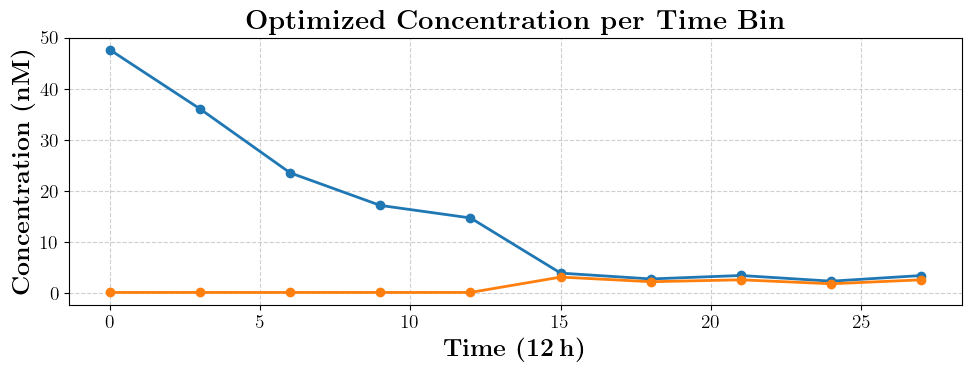

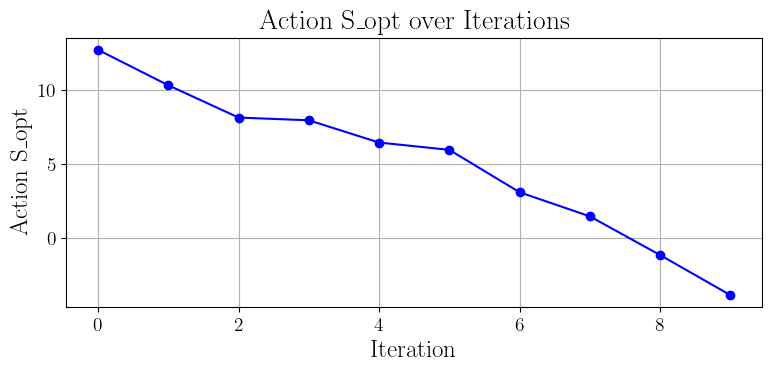

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Convert tensor to NumPy array
C_np = C_final.detach().cpu().numpy()

# Set large figure and font sizes
plt.figure(figsize=(10, 4))
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": True,
    "font.family": "serif"
})

# Plot
plt.plot(np.arange(0, len(C_np)) * T / n, C_np, marker='o', lw=2)

# Labels and formatting
plt.title(r"\textbf{Optimized Concentration per Time Bin}")
plt.xlabel(r"\textbf{Time (12\,h)}")
plt.ylabel(r"\textbf{Concentration (nM)}")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(history[1], marker='o', linestyle='-', color='blue')
plt.title("Action S_opt over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Action S_opt")
plt.grid(True)
plt.tight_layout()
plt.show()

    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.064  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    2  t=  0.02  N=  2001.3  Ω=  0.064  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    3  t=  0.03  N=  2001.3  Ω=  0.063  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    4  t=  0.04  N=  2001.3  Ω=  0.062  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    5  t=  0.05  N=  2001.3  Ω=  0.061  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    6  t=  0.06  N=  2001.3  Ω=  0.060  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    7  t=  0.07  N=  2001.3  Ω=  0.059  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    8  t=  0.08  N=  2001.3  Ω=  0.058  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
    9  t=  0.09  N=  2001.3  Ω=  0.057  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   10  t=  0.10  N=  2001.3  Ω=  0.056  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   11  t=  0.11  N=  2001.3  Ω=  0.055  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   12  t=  0.12  N=  2001.3  Ω=  0.054  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   13  t=  0.13  N=  2001.3 

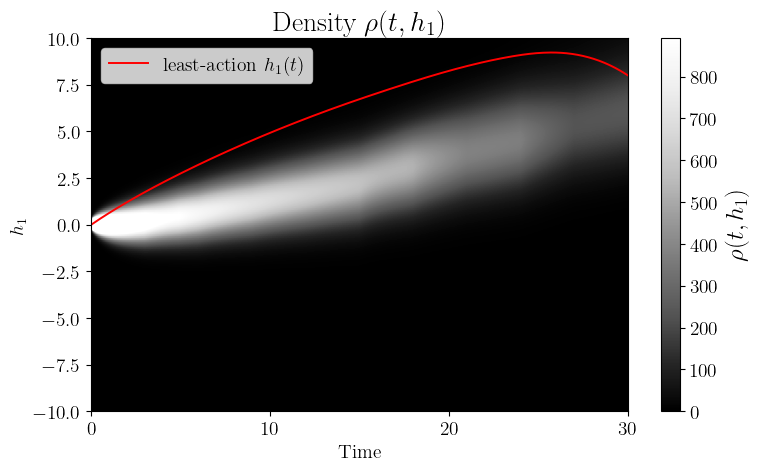

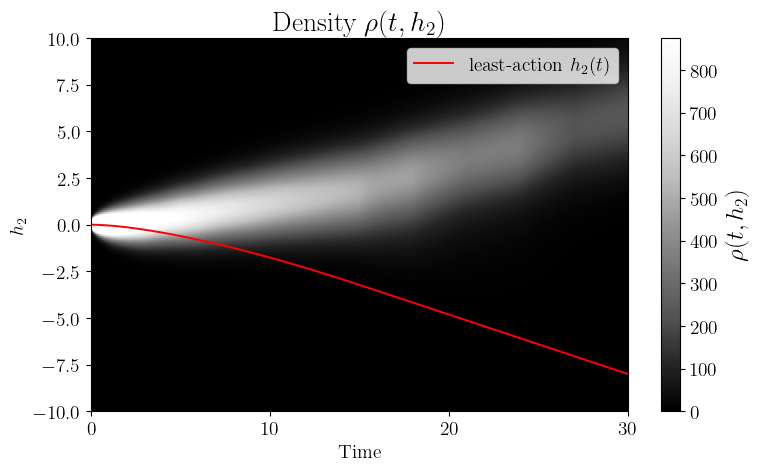

S_opt = 1.357536e+01   S_lin = 3.557093e+01   ΔS = 2.199556e+01


In [45]:
# ------------------------------------------------------------------
# 1. Extract times from a dummy FP run to build bin mapping
# ------------------------------------------------------------------
fp_probe = run_fp(S_mat, lambda t, v: 5, T=T, verbose=False)
times_np = np.asarray(fp_probe["times"])
t0, tf   = times_np[0], times_np[-1]
n_bins   = len(C_final)
bin_width = (tf - t0) / n_bins

# ------------------------------------------------------------------
# 2. Define a concentration function using the optimized bins
# ------------------------------------------------------------------
C_final_np = C_final.detach().cpu().numpy()



def get_C_final(t, a, C_arr=C_final_np, t0=t0, bw=bin_width):
    idx = int((t - t0) // bw)
    if idx > n-1:
        idx = n-1
    return float(C_arr[idx, a])           # scalar – no grad


# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C_final, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8,-8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r", sol=sol)
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r", dim=1, sol=sol)

S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results={}
results['copt']=fp_ctx_safe


# Second spike of antigen at Ti

# AIm 8 0

In [46]:
import numpy as np, torch, copy, math, os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")

# ---------------------------------------------------------------------
#  optimise_multiC_20  –  two-phase freezing / learning schedule
# ---------------------------------------------------------------------
def optimise_multiC_20(
    hf, S_mat, *,
    C0=5.0,               # learnable value (whichever antigen is "on")
    C1=5.0,               # clamped value (whichever antigen is "off")
    Ti=30.0,              # switch time (same unit as FP simulation)
    lr=0.20,
    n_steps=25,
    tol=1e-4,
    T=60.0,
    verbose=True,
    n=20                  # #bins (equal width)
):
    """
    Learns log-concentrations L_bins ∈ ℝ^{n × n_A} with the rule:

        • for t < Ti   : Ag-1 learnable (≈C0),  Ag-2 frozen at C1
        • for t ≥ Ti   : Ag-1 frozen   at C1,   Ag-2 learnable (≈C0)

    Other antigens, if present, are always learnable (init C0).
    """

    # ------------------------------------------------------------------
    # ①  Timeline and bin mapping
    # ------------------------------------------------------------------
    fp_probe = run_fp(S_mat, lambda t, v: C0, T=T, verbose=False)
    times_np = np.asarray(fp_probe["times"])
    t0, tf   = times_np[0], times_np[-1]

    bin_width = (tf - t0) / n
    bin_idx = torch.tensor(
        np.clip(np.floor((times_np - t0) / bin_width).astype(int), 0, n - 1),
        dtype=torch.long
    )
    times_t = torch.as_tensor(times_np, dtype=torch.float64)

    Ti_bin = int(max(0, math.floor((Ti - t0) / bin_width)))   # first bin with start ≥ Ti

    # ------------------------------------------------------------------
    # ②  Parameter tensor L_bins
    # ------------------------------------------------------------------
    _, n_A = S_mat.shape
    L_bins = torch.empty((n, n_A), dtype=torch.float64)

    # --- antigen 1 (index 0) ------------------------------------------
    L_bins[:Ti_bin, 0] = math.log(C0)    # learnable before Ti
    L_bins[Ti_bin:, 0] = math.log(C1)    # clamped  at C1 after Ti

    # --- antigen 2 (index 1) ------------------------------------------
    if n_A >= 2:
        L_bins[:Ti_bin, 1] = math.log(C1)    # clamped  at C1 before Ti
        L_bins[Ti_bin:, 1] = math.log(C0)    # learnable after Ti

    # --- other antigens ------------------------------------------------
    if n_A > 2:
        L_bins[:, 2:] = math.log(C0)

    L_bins.requires_grad_()

    # Mask of parameters that **never** receive gradient
    frozen_mask_bins = torch.zeros_like(L_bins, dtype=torch.bool)
    if n_A >= 2:
        frozen_mask_bins[:Ti_bin, 1] = True      # Ag-2 before Ti
        frozen_mask_bins[Ti_bin:, 0] = True      # Ag-1 after Ti

    hist_C, hist_S = [], []

    # ------------------------------------------------------------------
    # ③  Optimisation loop
    # ------------------------------------------------------------------
    for it in range(n_steps):
        if verbose:
            print(f"\n▶ iteration {it+1:02d}/{n_steps}")

        # ---- build C_param (n_times × n_A) ----------------------------
        C_bins  = torch.exp(L_bins)              # (n, n_A)
        C_param = C_bins[bin_idx, :].clone()     # (n_times, n_A)

        if n_A >= 2:
            mask_pre  = (times_t < Ti)           # bool mask snapshots
            mask_post = ~mask_pre

            # clamp values (detached constants, break graph)
            C_param[mask_pre,  1] = C1   # Ag-2 frozen before Ti
            C_param[mask_post, 0] = C1   # Ag-1 frozen after Ti

        # ---------- FP context ----------------------------------------
        C_det = C_param.detach().cpu().numpy()

        def get_C_piece(t, a, C_arr=C_det):
            idx_snap = int((t - t0) // bin_width)
            idx_snap = min(max(idx_snap, 0), len(times_np) - 1)
            return float(C_arr[idx_snap, a])

        def get_C_granular(t, a, C_arr=C_param):
            idx_snap = torch.argmin(torch.abs(times_t - t))
            return C_arr[idx_snap, a]

        fp_ctx = run_fp(S_mat, get_C_piece, T=T, verbose=False)
        fp_ctx["get_C"] = get_C_granular

        # ---------- optimal trajectory & action -----------------------
        sol = solve_optimal_trajectory(
            hf, copy.deepcopy(fp_ctx), mesh=100, plot=False
        )

        S_opt, S_lin = compute_least_action_torch_bis(
            sol, fp_ctx, C_param=C_param,
            baseline=True, verbose=False
        )

        # ---------- backward ------------------------------------------
        if L_bins.grad is not None:
            L_bins.grad.zero_()
        S_opt.backward()

        grad_L = L_bins.grad.detach()
        grad_L = grad_L.masked_fill(frozen_mask_bins, 0.0)

        gmax = grad_L.abs().max().item()
        if verbose:
            print(f"   S = {S_opt.item():.6e}    ‖∇S‖_∞ = {gmax:.2e}")
            print("   C_bins  (shape n×n_A):")
            print(C_bins.detach().cpu().numpy())
            print("   grad log (same shape):")
            print(grad_L.cpu().numpy())

        hist_C.append(C_bins.detach().cpu().numpy().copy())
        hist_S.append(S_opt.item())

        if gmax < tol:
            if verbose:
                print("   ✅ reached tolerance – stopping.")
            break

        # ---------- parameter update ----------------------------------
        with torch.no_grad():
            L_bins -= lr * grad_L
            L_bins.clamp_(min=-20.0)

        L_bins.grad = None

    return (np.array(hist_C), np.array(hist_S)), torch.exp(L_bins)


In [47]:
S_mat = np.array([[1.,1],[1,0]], dtype=float)   # two h‑coords, one antigen
hf    = [8,0]
n=10
T=30
(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=30.,C1=0.1, lr=0.2, n_steps=10, tol=1e-4, verbose=True, T=T, n=n, Ti=15
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))


▶ iteration 01/10
   S = 5.008295e+00    ‖∇S‖_∞ = 8.98e-01
   C_bins  (shape n×n_A):
[[30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]]
   grad log (same shape):
[[-0.8978212   0.        ]
 [-0.32502605  0.        ]
 [ 0.01735218  0.        ]
 [ 0.6520004   0.        ]
 [ 0.59553932  0.        ]
 [ 0.          0.86552841]
 [ 0.          0.81180381]
 [ 0.          0.75932077]
 [ 0.          0.70822645]
 [ 0.          0.62186609]]

▶ iteration 02/10
   S = 2.951203e+00    ‖∇S‖_∞ = 1.03e+00
   C_bins  (shape n×n_A):
[[35.90087333  0.1       ]
 [32.0149375   0.1       ]
 [29.89606737  0.1       ]
 [26.33232577  0.1       ]
 [26.63136128  0.1       ]
 [ 0.1        25.23146178]
 [ 0.1        25.50403358]
 [ 0.1        25.77314936]
 [ 0.1        26.03787193]
 [ 0.1        26.49150628]]
   grad log (same shape):
[[-0.81617852  0.        ]
 [-0.33374062  0.        ]
 [ 0.4936769   0.        ]
 [ 0.77304425  0.     

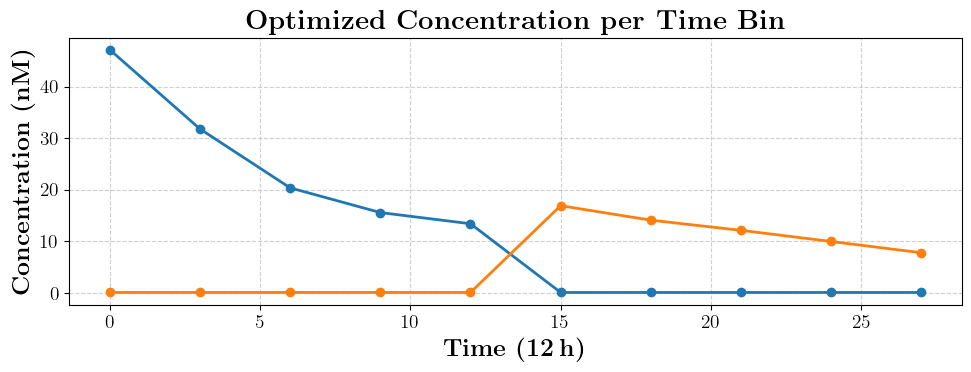

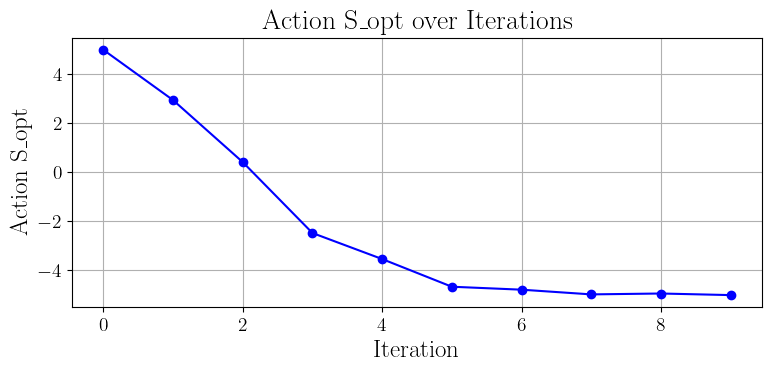

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Convert tensor to NumPy array
C_np = C_final.detach().cpu().numpy()

# Set large figure and font sizes
plt.figure(figsize=(10, 4))
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": True,
    "font.family": "serif"
})

# Plot
plt.plot(np.arange(0, len(C_np)) * T / n, C_np, marker='o', lw=2)

# Labels and formatting
plt.title(r"\textbf{Optimized Concentration per Time Bin}")
plt.xlabel(r"\textbf{Time (12\,h)}")
plt.ylabel(r"\textbf{Concentration (nM)}")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(history[1], marker='o', linestyle='-', color='blue')
plt.title("Action S_opt over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Action S_opt")
plt.grid(True)
plt.tight_layout()
plt.show()

    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.059  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    2  t=  0.02  N=  2001.2  Ω=  0.059  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    3  t=  0.03  N=  2001.2  Ω=  0.058  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    4  t=  0.04  N=  2001.2  Ω=  0.057  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    5  t=  0.05  N=  2001.2  Ω=  0.056  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    6  t=  0.06  N=  2001.2  Ω=  0.055  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    7  t=  0.07  N=  2001.2  Ω=  0.054  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    8  t=  0.08  N=  2001.2  Ω=  0.053  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
    9  t=  0.09  N=  2001.2  Ω=  0.052  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   10  t=  0.10  N=  2001.2  Ω=  0.051  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   11  t=  0.11  N=  2001.2  Ω=  0.050  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   12  t=  0.12  N=  2001.2  Ω=  0.049  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   13  t=  0.13  N=  2001.2 

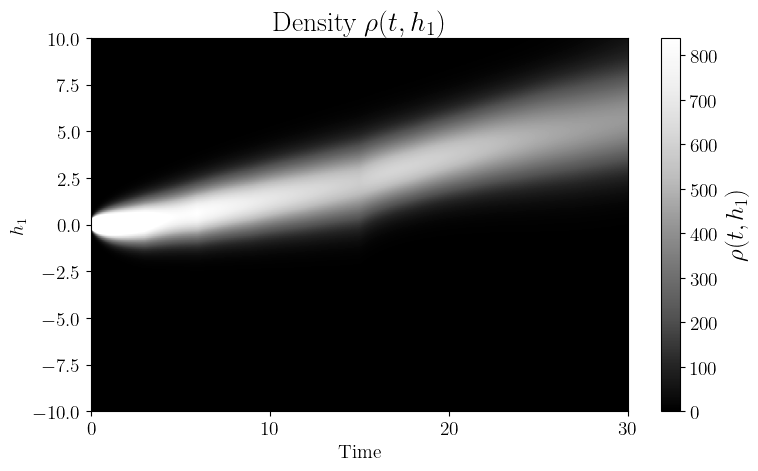

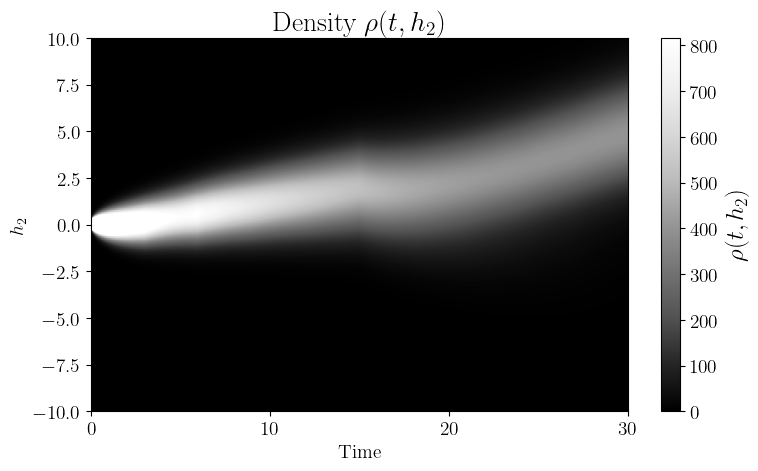

S_opt = 1.303431e+00   S_lin = 5.884566e+00   ΔS = 4.581135e+00


In [49]:
# ------------------------------------------------------------------
# 1. Extract times from a dummy FP run to build bin mapping
# ------------------------------------------------------------------
fp_probe = run_fp(S_mat, lambda t, v: 5, T=T, verbose=False)
times_np = np.asarray(fp_probe["times"])
t0, tf   = times_np[0], times_np[-1]
n_bins   = len(C_final)
bin_width = (tf - t0) / n_bins

# ------------------------------------------------------------------
# 2. Define a concentration function using the optimized bins
# ------------------------------------------------------------------
C_final_np = C_final.detach().cpu().numpy()



def get_C_final(t, a, C_arr=C_final_np, t0=t0, bw=bin_width):
    idx = int((t - t0) // bw)
    if idx > n-1:
        idx = n-1
    return float(C_arr[idx, a])           # scalar – no grad


# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C_final, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8,0], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r", dim=1)

S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results={}
results['copt']=fp_ctx_safe

# Aim 8 8

In [50]:
S_mat = np.array([[1.,1],[1,0]], dtype=float)   # two h‑coords, one antigen
hf    = [8,8]
n=10
T=30
(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=30.,C1=0.1, lr=0.2, n_steps=10, tol=1e-4, verbose=True, T=T, n=n, Ti=15
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))


▶ iteration 01/10
   S = 1.236167e+01    ‖∇S‖_∞ = 9.05e-01
   C_bins  (shape n×n_A):
[[30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]]
   grad log (same shape):
[[-0.80959269  0.        ]
 [-0.19384503  0.        ]
 [ 0.11412877  0.        ]
 [ 0.72149663  0.        ]
 [ 0.65037113  0.        ]
 [ 0.          0.90503165]
 [ 0.          0.85990926]
 [ 0.          0.81652099]
 [ 0.          0.78102302]
 [ 0.          0.71751077]]

▶ iteration 02/10
   S = 1.042820e+01    ‖∇S‖_∞ = 1.08e+00
   C_bins  (shape n×n_A):
[[35.27293369  0.1       ]
 [31.18590993  0.1       ]
 [29.32298346  0.1       ]
 [25.96885812  0.1       ]
 [26.34090765  0.1       ]
 [ 0.1        25.03290232]
 [ 0.1        25.25983359]
 [ 0.1        25.47998349]
 [ 0.1        25.66152471]
 [ 0.1        25.98956802]]
   grad log (same shape):
[[-0.73558692  0.        ]
 [-0.19602253  0.        ]
 [ 0.60737877  0.        ]
 [ 0.86184438  0.     

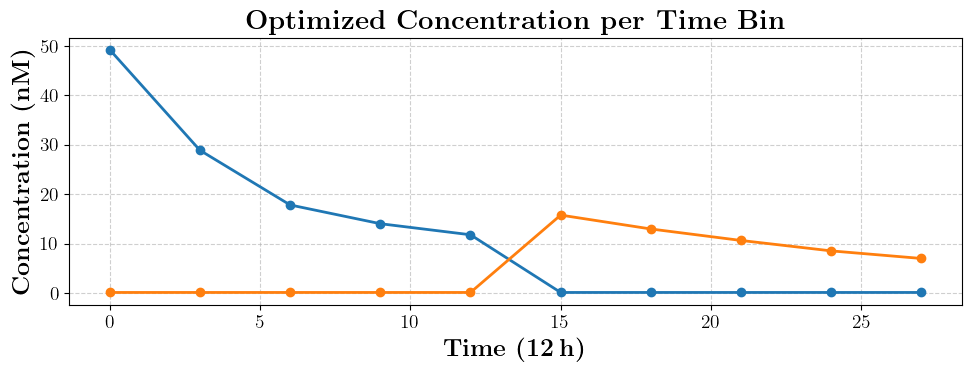

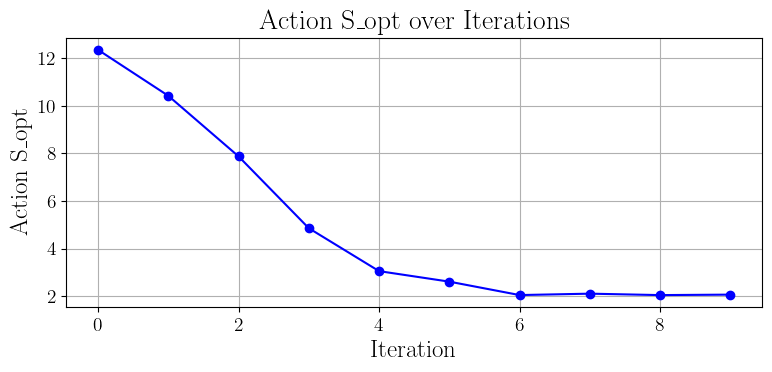

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Convert tensor to NumPy array
C_np = C_final.detach().cpu().numpy()

# Set large figure and font sizes
plt.figure(figsize=(10, 4))
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": True,
    "font.family": "serif"
})

# Plot
plt.plot(np.arange(0, len(C_np)) * T / n, C_np, marker='o', lw=2)

# Labels and formatting
plt.title(r"\textbf{Optimized Concentration per Time Bin}")
plt.xlabel(r"\textbf{Time (12\,h)}")
plt.ylabel(r"\textbf{Concentration (nM)}")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(history[1], marker='o', linestyle='-', color='blue')
plt.title("Action S_opt over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Action S_opt")
plt.grid(True)
plt.tight_layout()
plt.show()

    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.077  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    2  t=  0.02  N=  2001.6  Ω=  0.077  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    3  t=  0.03  N=  2001.6  Ω=  0.076  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    4  t=  0.04  N=  2001.6  Ω=  0.075  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    5  t=  0.05  N=  2001.6  Ω=  0.074  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    6  t=  0.06  N=  2001.6  Ω=  0.073  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    7  t=  0.07  N=  2001.6  Ω=  0.072  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    8  t=  0.08  N=  2001.6  Ω=  0.071  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
    9  t=  0.09  N=  2001.6  Ω=  0.070  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   10  t=  0.10  N=  2001.6  Ω=  0.069  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   11  t=  0.11  N=  2001.6  Ω=  0.068  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   12  t=  0.12  N=  2001.6  Ω=  0.067  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   13  t=  0.13  N=  2001.6 

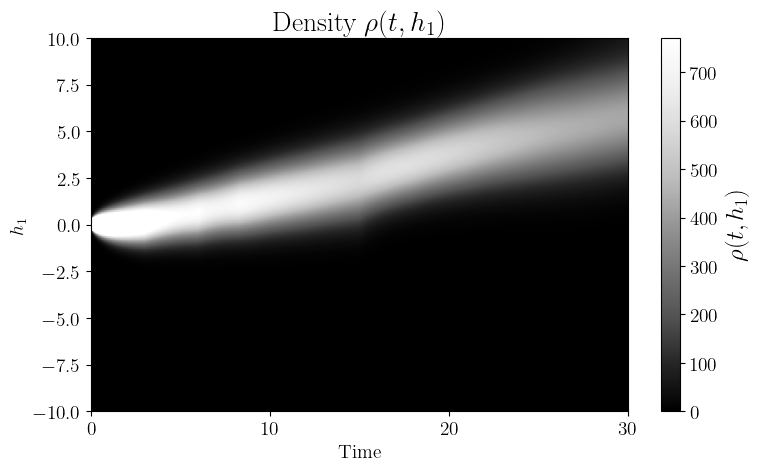

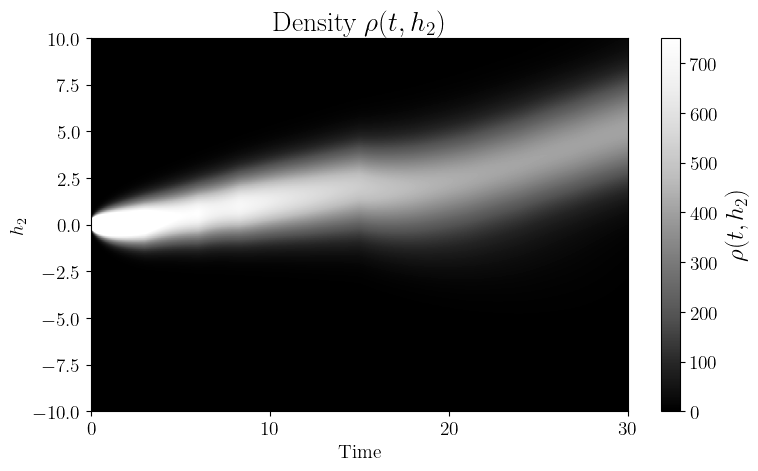

S_opt = 1.874790e+00   S_lin = 7.848985e+00   ΔS = 5.974195e+00


In [52]:
# ------------------------------------------------------------------
# 1. Extract times from a dummy FP run to build bin mapping
# ------------------------------------------------------------------
fp_probe = run_fp(S_mat, lambda t, v: 5, T=T, verbose=False)
times_np = np.asarray(fp_probe["times"])
t0, tf   = times_np[0], times_np[-1]
n_bins   = len(C_final)
bin_width = (tf - t0) / n_bins

# ------------------------------------------------------------------
# 2. Define a concentration function using the optimized bins
# ------------------------------------------------------------------
C_final_np = C_final.detach().cpu().numpy()



def get_C_final(t, a, C_arr=C_final_np, t0=t0, bw=bin_width):
    idx = int((t - t0) // bw)
    if idx > n-1:
        idx = n-1
    return float(C_arr[idx, a])           # scalar – no grad


# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C_final, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8,0], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r", dim=1)

S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results={}
results['copt']=fp_ctx_safe

# Aim 8 -8

In [53]:
S_mat = np.array([[1.,1],[1,0]], dtype=float)   # two h‑coords, one antigen
hf    = [8,-8]
n=10
T=30
(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=30.,C1=0.1, lr=0.2, n_steps=10, tol=1e-4, verbose=True, T=T, n=n, Ti=15
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))


▶ iteration 01/10
   S = 1.000961e+01    ‖∇S‖_∞ = 9.54e-01
   C_bins  (shape n×n_A):
[[30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [30.   0.1]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]
 [ 0.1 30. ]]
   grad log (same shape):
[[-0.95390088  0.        ]
 [-0.43412468  0.        ]
 [-0.0981836   0.        ]
 [ 0.53635881  0.        ]
 [ 0.47720573  0.        ]
 [ 0.          0.88022262]
 [ 0.          0.82018625]
 [ 0.          0.76096559]
 [ 0.          0.69375643]
 [ 0.          0.56214025]]

▶ iteration 02/10
   S = 7.835541e+00    ‖∇S‖_∞ = 1.06e+00
   C_bins  (shape n×n_A):
[[36.30580183  0.1       ]
 [32.72117161  0.1       ]
 [30.59492365  0.1       ]
 [26.94844564  0.1       ]
 [27.26915568  0.1       ]
 [ 0.1        25.15741939]
 [ 0.1        25.46131222]
 [ 0.1        25.76467231]
 [ 0.1        26.11333479]
 [ 0.1        26.8098493 ]]
   grad log (same shape):
[[-0.86401316  0.        ]
 [-0.43907929  0.        ]
 [ 0.46526725  0.        ]
 [ 0.63766327  0.     

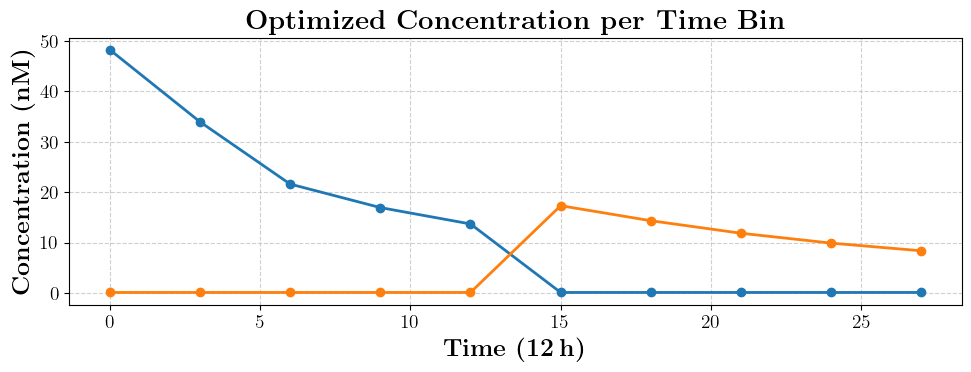

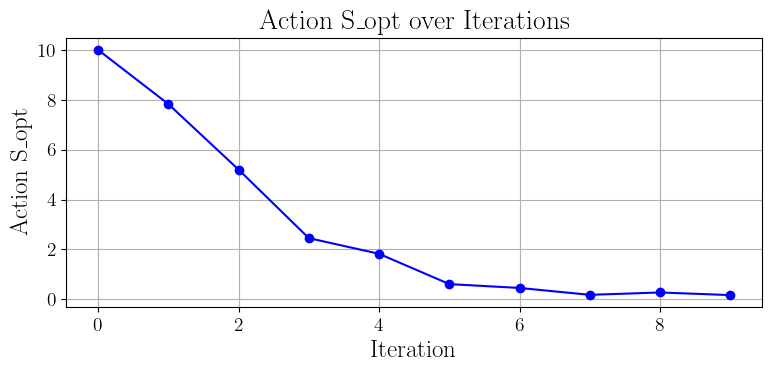

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Convert tensor to NumPy array
C_np = C_final.detach().cpu().numpy()

# Set large figure and font sizes
plt.figure(figsize=(10, 4))
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": True,
    "font.family": "serif"
})

# Plot
plt.plot(np.arange(0, len(C_np)) * T / n, C_np, marker='o', lw=2)

# Labels and formatting
plt.title(r"\textbf{Optimized Concentration per Time Bin}")
plt.xlabel(r"\textbf{Time (12\,h)}")
plt.ylabel(r"\textbf{Concentration (nM)}")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(history[1], marker='o', linestyle='-', color='blue')
plt.title("Action S_opt over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Action S_opt")
plt.grid(True)
plt.tight_layout()
plt.show()

    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.069  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    2  t=  0.02  N=  2001.4  Ω=  0.069  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    3  t=  0.03  N=  2001.4  Ω=  0.068  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    4  t=  0.04  N=  2001.4  Ω=  0.067  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    5  t=  0.05  N=  2001.4  Ω=  0.066  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    6  t=  0.06  N=  2001.4  Ω=  0.065  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    7  t=  0.07  N=  2001.4  Ω=  0.064  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    8  t=  0.08  N=  2001.4  Ω=  0.063  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
    9  t=  0.09  N=  2001.4  Ω=  0.062  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   10  t=  0.10  N=  2001.4  Ω=  0.061  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   11  t=  0.11  N=  2001.4  Ω=  0.060  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   12  t=  0.12  N=  2001.4  Ω=  0.059  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   13  t=  0.13  N=  2001.4 

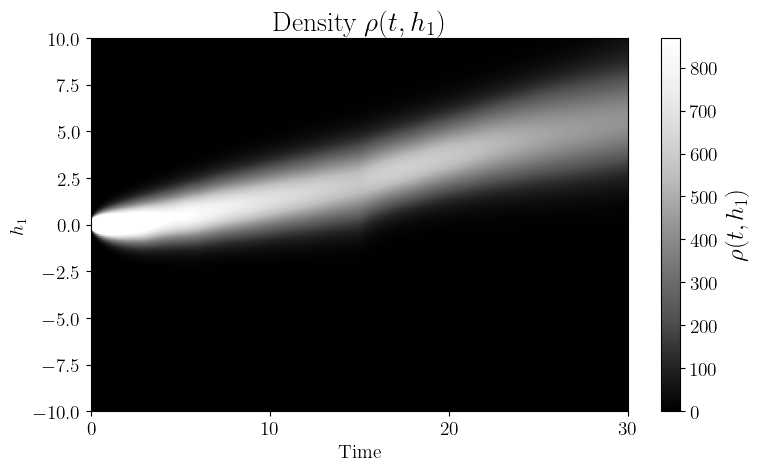

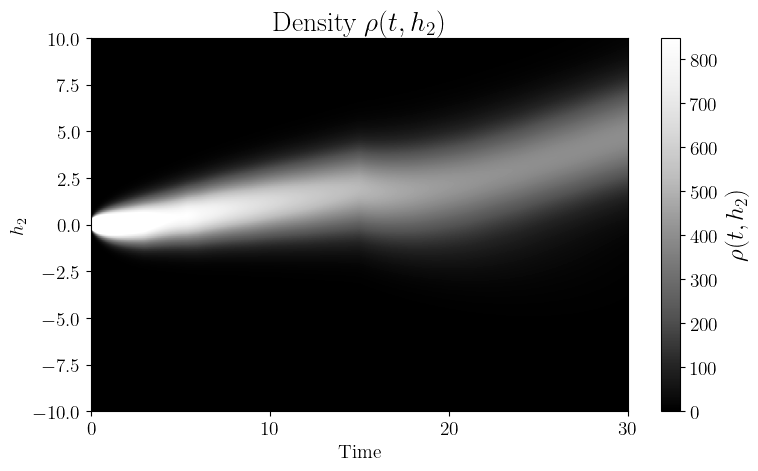

S_opt = 7.878653e+00   S_lin = 2.155044e+01   ΔS = 1.367179e+01


In [55]:
# ------------------------------------------------------------------
# 1. Extract times from a dummy FP run to build bin mapping
# ------------------------------------------------------------------
fp_probe = run_fp(S_mat, lambda t, v: 5, T=T, verbose=False)
times_np = np.asarray(fp_probe["times"])
t0, tf   = times_np[0], times_np[-1]
n_bins   = len(C_final)
bin_width = (tf - t0) / n_bins

# ------------------------------------------------------------------
# 2. Define a concentration function using the optimized bins
# ------------------------------------------------------------------
C_final_np = C_final.detach().cpu().numpy()



def get_C_final(t, a, C_arr=C_final_np, t0=t0, bw=bin_width):
    idx = int((t - t0) // bw)
    if idx > n-1:
        idx = n-1
    return float(C_arr[idx, a])           # scalar – no grad


# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C_final, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8,-8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r", dim=1)

S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results={}
results['copt']=fp_ctx_safe

# WT | WT+Ag

In [59]:
import numpy as np, torch, copy, math, os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")

# ---------------------------------------------------------------------
#  optimise_multiC_20  –  antigen-specific freezing until Ti
# ---------------------------------------------------------------------
def optimise_multiC_20(
    hf, S_mat, *,
    C0=5.0,               # learnable initial value
    C1=5.0,               # clamped value for Ag-2 before Ti
    Ti=30.0,              # switch time
    lr=0.20,
    n_steps=25,
    tol=1e-4,
    T=60.0,               # FP horizon
    verbose=True,
    n=20                  # number of equal-width time bins
):
    """
    Learning schedule
    -----------------
    • t < Ti :  Ag-1 learnable (≈C0) ;  Ag-2 clamped at C1
    • t ≥ Ti :  Ag-1 learnable ;       Ag-2 learnable (≈C0)

    All other antigens always learnable, init C0.
    """

    # ------------------------------------------------------------------
    # ①  Timeline and bin mapping
    # ------------------------------------------------------------------
    fp_probe = run_fp(S_mat, lambda t, v: C0, T=T, verbose=False)
    times_np = np.asarray(fp_probe["times"])
    t0, tf   = times_np[0], times_np[-1]

    bin_width = (tf - t0) / n
    bin_idx = torch.tensor(
        np.clip(np.floor((times_np - t0) / bin_width).astype(int), 0, n - 1),
        dtype=torch.long
    )
    times_t = torch.as_tensor(times_np, dtype=torch.float64)

    Ti_bin = int(max(0, math.floor((Ti - t0) / bin_width)))   # first bin with start ≥ Ti

    # ------------------------------------------------------------------
    # ②  Parameter tensor L_bins
    # ------------------------------------------------------------------
    _, n_A = S_mat.shape
    L_bins = torch.empty((n, n_A), dtype=torch.float64)

    # Antigen-1 (index 0): always learnable, init C0 everywhere
    L_bins[:, 0] = math.log(C0)

    # Antigen-2 (index 1): clamped to C1 before Ti, learnable (C0) after Ti
    if n_A >= 2:
        L_bins[:Ti_bin, 1] = math.log(C1)   # frozen part
        L_bins[Ti_bin:, 1] = math.log(C0)   # learnable part

    # Other antigens (≥2): fully learnable, init C0
    if n_A > 2:
        L_bins[:, 2:] = math.log(C0)

    L_bins.requires_grad_()

    # Freeze mask: only Ag-2 bins before Ti are frozen
    frozen_mask_bins = torch.zeros_like(L_bins, dtype=torch.bool)
    if n_A >= 2:
        frozen_mask_bins[:Ti_bin, 1] = True

    hist_C, hist_S = [], []

    # ------------------------------------------------------------------
    # ③  Optimisation loop
    # ------------------------------------------------------------------
    for it in range(n_steps):
        if verbose:
            print(f"\n▶ iteration {it+1:02d}/{n_steps}")

        # ---- build C_param (n_times × n_A) ----------------------------
        C_bins  = torch.exp(L_bins)              # (n, n_A)
        C_param = C_bins[bin_idx, :].clone()     # (n_times, n_A)

        if n_A >= 2:
            mask_pre = (times_t < Ti)
            # clamp Ag-2 before Ti to C1 (detached => no gradient path)
            C_param[mask_pre, 1] = C1

        # ---------- FP context ----------------------------------------
        C_det = C_param.detach().cpu().numpy()

        def get_C_piece(t, a, C_arr=C_det):
            idx_snap = int((t - t0) // bin_width)
            idx_snap = min(max(idx_snap, 0), len(times_np) - 1)
            return float(C_arr[idx_snap, a])

        def get_C_granular(t, a, C_arr=C_param):
            idx_snap = torch.argmin(torch.abs(times_t - t))
            return C_arr[idx_snap, a]

        fp_ctx = run_fp(S_mat, get_C_piece, T=T, verbose=False)
        fp_ctx["get_C"] = get_C_granular

        # ---------- optimal trajectory & action -----------------------
        sol = solve_optimal_trajectory(
            hf, copy.deepcopy(fp_ctx), mesh=100, plot=False
        )

        S_opt, S_lin = compute_least_action_torch_bis(
            sol, fp_ctx, C_param=C_param,
            baseline=True, verbose=False
        )

        # ---------- backward ------------------------------------------
        if L_bins.grad is not None:
            L_bins.grad.zero_()
        S_opt.backward()

        grad_L = L_bins.grad.detach()
        grad_L = grad_L.masked_fill(frozen_mask_bins, 0.0)  # zero frozen grads

        gmax = grad_L.abs().max().item()
        if verbose:
            print(f"   S = {S_opt.item():.6e}    ‖∇S‖_∞ = {gmax:.2e}")
            print("   C_bins  (shape n×n_A):")
            print(C_bins.detach().cpu().numpy())
            print("   grad log (same shape):")
            print(grad_L.cpu().numpy())

        hist_C.append(C_bins.detach().cpu().numpy().copy())
        hist_S.append(S_opt.item())

        if gmax < tol:
            if verbose:
                print("   ✅ reached tolerance – stopping.")
            break

        # ---------- parameter update ----------------------------------
        with torch.no_grad():
            L_bins -= lr * grad_L
            L_bins.clamp_(min=-20.0)

        L_bins.grad = None

    return (np.array(hist_C), np.array(hist_S)), torch.exp(L_bins)


In [61]:
S_mat = np.array([[1.,1],[1,0]], dtype=float)   # two h‑coords, one antigen
hf    = [8,0]
n=10
T=30
(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=5.,C1=0.1, lr=0.5, n_steps=10, tol=1e-4, verbose=True, T=T, n=n, Ti=15
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))


▶ iteration 01/10
   S = 1.377110e+01    ‖∇S‖_∞ = 1.75e+00
   C_bins  (shape n×n_A):
[[5.  0.1]
 [5.  0.1]
 [5.  0.1]
 [5.  0.1]
 [5.  0.1]
 [5.  5. ]
 [5.  5. ]
 [5.  5. ]
 [5.  5. ]
 [5.  5. ]]
   grad log (same shape):
[[-1.7509853   0.        ]
 [-0.5039575   0.        ]
 [-0.19738695  0.        ]
 [-0.13019876  0.        ]
 [-0.12372642  0.        ]
 [-0.04261204 -0.04147893]
 [-0.06981966 -0.06938834]
 [-0.15710087 -0.15688772]
 [-0.51053493 -0.51035011]
 [-1.21012764 -1.20984528]]

▶ iteration 02/10
   S = 7.398189e+00    ‖∇S‖_∞ = 1.34e+00
   C_bins  (shape n×n_A):
[[12.00028695  0.1       ]
 [ 6.43284348  0.1       ]
 [ 5.51863964  0.1       ]
 [ 5.33632541  0.1       ]
 [ 5.31908407  0.1       ]
 [ 5.10767306  5.10478012]
 [ 5.17763166  5.17651518]
 [ 5.40858954  5.40801316]
 [ 6.45403409  6.45343772]
 [ 9.1568454   9.15555275]]
   grad log (same shape):
[[-1.33815293  0.        ]
 [-0.73487513  0.        ]
 [-0.38388259  0.        ]
 [-0.25111841  0.        ]
 [-0.21405864  

KeyboardInterrupt: 

    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.163  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    2  t=  0.02  N=  2003.3  Ω=  0.163  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    3  t=  0.03  N=  2003.3  Ω=  0.162  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    4  t=  0.04  N=  2003.3  Ω=  0.161  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    5  t=  0.05  N=  2003.3  Ω=  0.160  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    6  t=  0.06  N=  2003.3  Ω=  0.160  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    7  t=  0.07  N=  2003.3  Ω=  0.159  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00  ⟨h_2⟩= -0.00
    8  t=  0.08  N=  2003.3  Ω=  0.158  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
    9  t=  0.09  N=  2003.3  Ω=  0.157  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   10  t=  0.10  N=  2003.3  Ω=  0.156  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   11  t=  0.11  N=  2003.3  Ω=  0.155  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   12  t=  0.12  N=  2003.3  Ω=  0.154  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01  ⟨h_2⟩= -0.01
   13  t=  0.13  N=  2003.3 

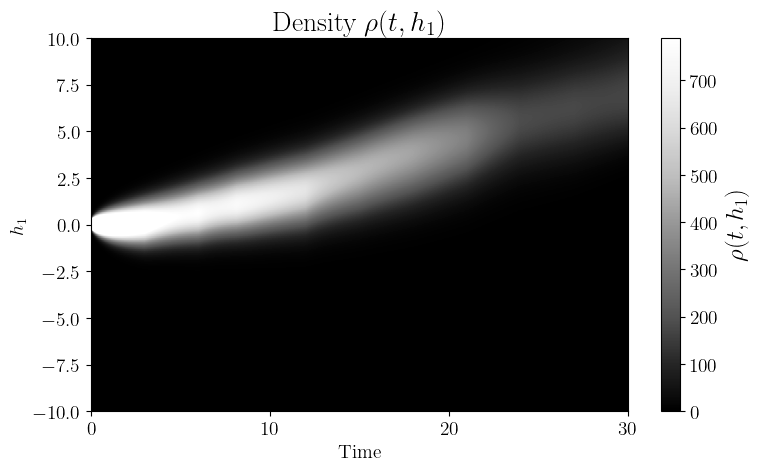

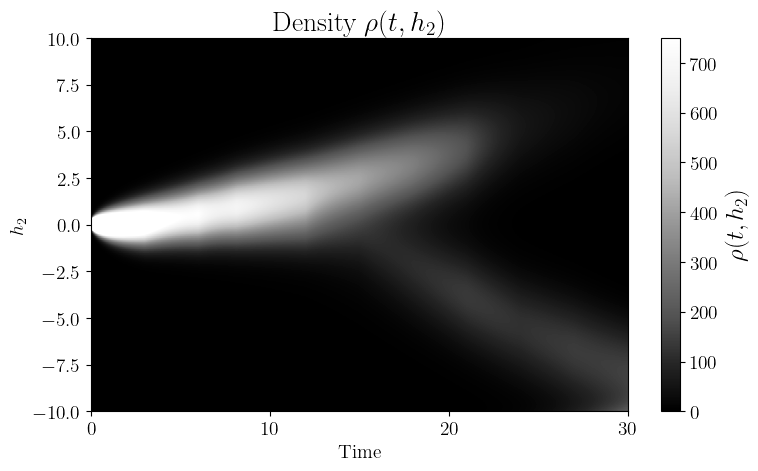

TypeError: compute_least_action_torch() missing 1 required positional argument: 'C_param'

In [ ]:
# ------------------------------------------------------------------
# 1. Extract times from a dummy FP run to build bin mapping
# ------------------------------------------------------------------
fp_probe = run_fp(S_mat, lambda t, v: 5, T=T, verbose=False)
times_np = np.asarray(fp_probe["times"])
t0, tf   = times_np[0], times_np[-1]
n_bins   = len(C_final)
bin_width = (tf - t0) / n_bins

# ------------------------------------------------------------------
# 2. Define a concentration function using the optimized bins
# ------------------------------------------------------------------
C_final_np = C_final.detach().cpu().numpy()



def get_C_final(t, a, C_arr=C_final_np, t0=t0, bw=bin_width):
    idx = int((t - t0) // bw)
    if idx > n-1:
        idx = n-1
    return float(C_arr[idx, a])           # scalar – no grad


# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C_final, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8,-8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r", dim=1)

S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results={}
results['copt']=fp_ctx_safe